# SECTION 1 — Environment Setup

# Housing Price Regression Experiment

This notebook evaluates the performance of:

- Single regression
- MixCobra and GradientCobra aggregation

on the Housing Price dataset.

Metrics:
- MAE
- MSE
- RMSE
- R2

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)


# SECTION 2 — Dataset Loading

In [3]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("camnugent/california-housing-prices")
os.listdir(path)


100%|██████████| 400k/400k [00:00<00:00, 590kB/s]

Extracting files...


['housing.csv']

In [4]:
df = pd.read_csv(os.path.join(path, "housing.csv"))
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# SECTION 3 — Exploratory Data Analysis

In [5]:
print(df.shape)
df.info()

(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# SECTION 4 — Data Preprocessing

In [7]:
target = "median_house_value"

X = df.drop(columns=[target])
y = df[target]

In [8]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols, num_cols

(['ocean_proximity'],
 ['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income'])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [11]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# SECTION 5 — Train Models

In [12]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "ridge": Ridge(alpha=1.0),
    "random_forest_regressor" : RandomForestRegressor(n_estimators=300, random_state=42),
    "svr": SVR(),
    "gradient_boosting_regressor" : GradientBoostingRegressor(),
    "k_neighbors_regressor": KNeighborsRegressor()
}

def evaluate_regression(y_true, y_pred):
    metrics = {
        "MAE" : mean_absolute_error(y_true, y_pred),
        "MSE" : mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2"  : r2_score(y_true, y_pred)
    }
    return metrics

In [13]:
results = {}
for name, model in models.items():
    reg = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)
    results[name] = metrics

In [23]:
from cobra.gradientcobra import GradientCOBRA

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

gradientcobra = GradientCOBRA(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
gradientcobra.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred = gradientcobra.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics = evaluate_regression(y_test, y_pred)
results["gradientcobra"] = metrics
print(f"Results for gradientcobra: {metrics}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [01:25<00:00,  3.53it/s]


Results for gradientcobra: {'MAE': 34319.709181026774, 'MSE': 2747350719.304769, 'RMSE': 52415.176421574404, 'R2': 0.7903440250392035}

Time computing : fit 91.0095924999332, predict 1.413191750063561


In [24]:
gradientcobra.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 7.525331103678931,
 'score': 2545803680.295672,
 'history':      iter         score          risk  bandwidth
 0       0  1.327956e+10  1.327956e+10   0.001000
 1       1  1.244106e+10  1.244106e+10   0.034441
 2       2  1.167033e+10  1.167033e+10   0.067883
 3       3  1.095959e+10  1.095959e+10   0.101324
 4       4  1.030233e+10  1.030233e+10   0.134766
 ..    ...           ...           ...        ...
 295   295  2.563677e+09  2.563677e+09   9.866234
 296   296  2.564152e+09  2.564152e+09   9.899676
 297   297  2.564633e+09  2.564633e+09   9.933117
 298   298  2.565120e+09  2.565120e+09   9.966559
 299   299  2.565611e+09  2.565611e+09  10.000000
 
 [300 rows x 4 columns],
 'evaluations': 300}

In [21]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,MAE,MSE,RMSE,R2
random_forest_regressor,31435.282816,2.373830e+09,48721.968199,0.818848
gradientcobra,35212.248116,2.824637e+09,53147.311039,0.784446
gradient_boosting_regressor,38286.079313,3.125516e+09,55906.311478,0.761485
k_neighbors_regressor,40763.476841,3.758886e+09,61309.752197,0.713152
ridge,50676.922171,4.909247e+09,70066.021121,0.625365
svr,87042.383432,1.366967e+10,116917.376082,-0.043161


<Axes: xlabel='bandwidth', ylabel='score'>

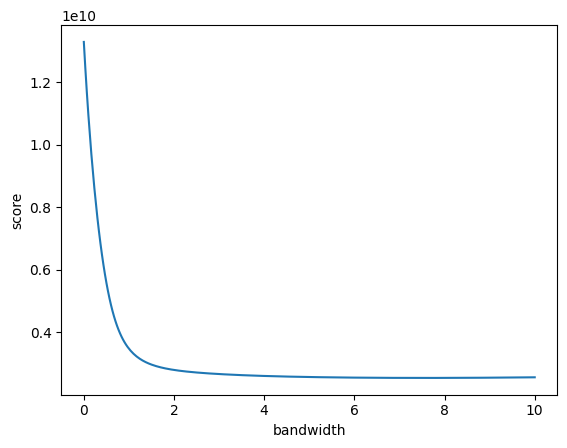

In [25]:
df_output = gradientcobra.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

# SECTION 6 — External training

In [26]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train_p,
    y_train,
    test_size=0.5,
    random_state=42,
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test_p)
    for m in fit_models.values()
])

gradientcobra = GradientCOBRA(
    estimators=fit_models.keys(),
    random_state=42,
)

gradientcobra.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = gradientcobra.predict(
    X=P_test
)

metrics = evaluate_regression(y_test, y_pred)
metrics


search: 100%|██████████| 300/300 [01:25<00:00,  3.52it/s]


{'MAE': 34039.85449683635,
 'MSE': 2738271981.7754817,
 'RMSE': 52328.500664317544,
 'R2': 0.7910368421428742}